# CatanBot — Training & Evaluation Notebook

This notebook trains the AlphaZero-style value network on your Catan dataset
and then evaluates it on held-out game replays. All results are saved to disk
and plotted inline.

**Prerequisites:**
```bash
conda env create -f environment.yml
conda activate catanbot
```

**Directory layout expected:**
```
project/
├── catan_network.py          # network + training code
├── evaluate_model.py         # evaluation script
├── encoder.py, state.py, ... # Catan framework modules
├── training_data/            # .npy memmap dataset from build_dataset.py
│   ├── features.npy
│   ├── labels.npy
│   ├── outcome_scores.npy
│   ├── position_scores.npy
│   ├── economic_scores.npy
│   ├── won_game.npy
│   └── manifest.json
├── dataset/                  # raw game JSONs (for evaluation)
│   ├── game_001.json
│   └── ...
└── checkpoints/              # created during training
```


## 1. Setup & Configuration

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [6]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/catanbot')  # your actual path

from model.catan_network import (
    CatanNet, CatanLoss, CatanTrainingDataset,
    WarmupCosineScheduler, Trainer, collate_fn,
)

In [8]:
import os
import json
import time
import glob
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from IPython.display import display, HTML

# Make plots appear inline
%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 120,
    "font.size": 11,
})

# ── Import our modules ──
from model.catan_network import (
    CatanNet, CatanLoss, CatanTrainingDataset,
    WarmupCosineScheduler, Trainer, collate_fn,
)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 14.6 GB


In [9]:
# ══════════════════════════════════════════════
# CONFIGURATION — Edit these paths for your setup
# ══════════════════════════════════════════════

# Path to the training dataset (directory of .npy files OR a .npz file)
DATA_PATH = "/content/drive/MyDrive/catanbot/training_data"

# Path to raw game JSONs (for evaluation)
GAMES_DIR = "/content/drive/MyDrive/catanbot/dataset"

# Training hyperparameters
CONFIG = {
    # Architecture
    "hidden_dim":    256,     # residual tower width (AlphaZero: 256)
    "num_blocks":    12,      # residual blocks (AlphaZero: 19-39, 12 is practical)
    "value_hidden":  128,     # value head hidden dim
    "dropout":       0.05,    # dropout in res blocks

    # Training
    "epochs":        60,
    "batch_size":    2048,    # increase if GPU memory allows
    "lr":            2e-3,    # peak learning rate
    "min_lr":        1e-6,
    "weight_decay":  1e-4,
    "warmup_epochs": 3,
    "grad_clip":     1.0,
    "patience":      15,      # early stopping patience
    "optimizer":     "adamw", # "adamw" or "sgd"

    # Loss weights
    "w_value":       1.0,     # primary value prediction
    "w_aux":         0.3,     # auxiliary sub-score prediction
    "w_win":         0.2,     # binary win classification

    # Infrastructure
    "amp":           True,    # mixed precision (disable if issues on your cluster)
    "workers":       4,       # DataLoader workers
    "val_split":     0.1,     # fraction held out for validation
    "ckpt_dir":      "checkpoints",
    "ckpt_every":    10,
    "log_dir":       "runs/catan",
    "seed":          42,

    # Evaluation
    "eval_max_games": 200,
    "eval_min_turn":  8,
}

print("Configuration set.")
print(f"  Data:   {DATA_PATH}")
print(f"  Games:  {GAMES_DIR}")
print(f"  Epochs: {CONFIG['epochs']}, Batch: {CONFIG['batch_size']}, LR: {CONFIG['lr']}")


Configuration set.
  Data:   /content/drive/MyDrive/catanbot/training_data
  Games:  /content/drive/MyDrive/catanbot/dataset
  Epochs: 60, Batch: 2048, LR: 0.002


## 2. Load Dataset

In [10]:
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

# Load
dataset = CatanTrainingDataset(DATA_PATH)

# Split
n = len(dataset)
n_val = int(n * CONFIG["val_split"])
n_train = n - n_val

generator = torch.Generator().manual_seed(CONFIG["seed"])
train_set, val_set = random_split(dataset, [n_train, n_val], generator=generator)

print(f"\nTrain: {n_train:,}  |  Val: {n_val:,}")


  Loaded 1,569,224 samples × 1363 features (memmap)
  Labels: mean=0.4799, std=0.1156
  Win rate: 24.42%

Train: 1,412,302  |  Val: 156,922


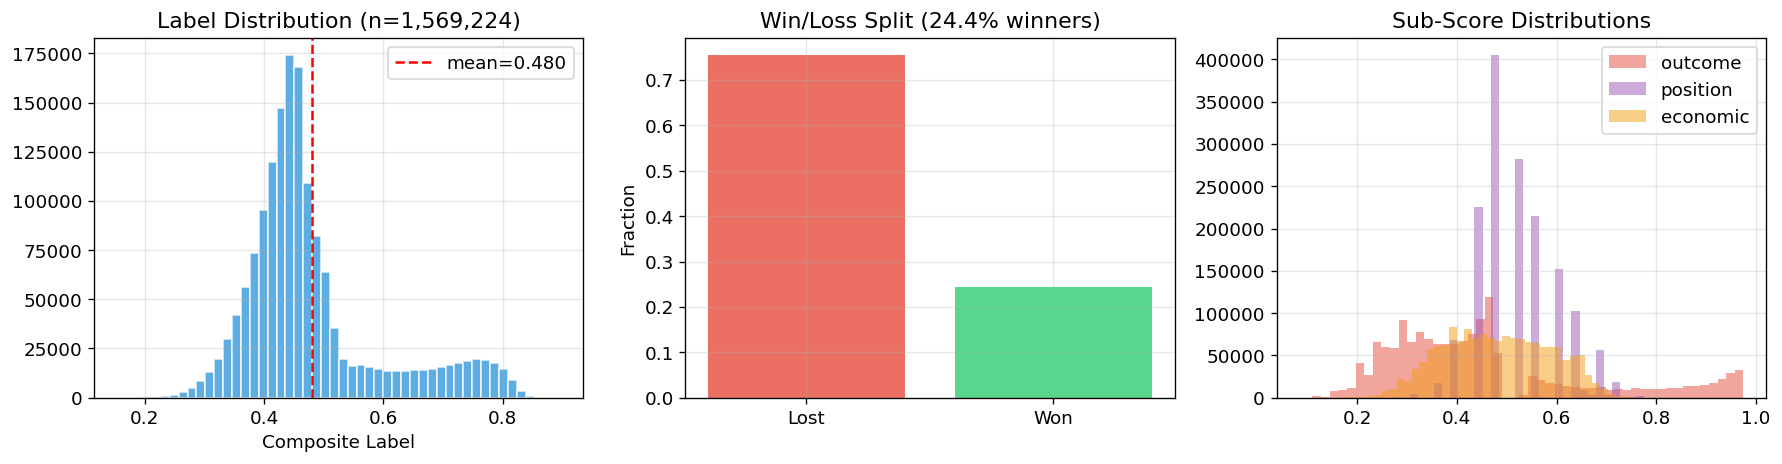

In [11]:
# Quick dataset inspection: label distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Labels
labels_arr = dataset.labels[:].numpy() if hasattr(dataset.labels, 'numpy') else np.array(dataset.labels[:])
axes[0].hist(labels_arr, bins=50, color="#3498db", alpha=0.8, edgecolor="white")
axes[0].set_title(f"Label Distribution (n={len(labels_arr):,})")
axes[0].set_xlabel("Composite Label")
axes[0].axvline(x=labels_arr.mean(), color="red", linestyle="--", label=f"mean={labels_arr.mean():.3f}")
axes[0].legend()

# Won game distribution
if dataset.has_win:
    won_arr = np.array(dataset.won_game[:], dtype=float)
    axes[1].bar(["Lost", "Won"], [1 - won_arr.mean(), won_arr.mean()],
                color=["#e74c3c", "#2ecc71"], alpha=0.8)
    axes[1].set_title(f"Win/Loss Split ({won_arr.mean():.1%} winners)")
    axes[1].set_ylabel("Fraction")

# Sub-scores
if dataset.has_aux:
    for name, color in [("outcome_scores", "#e74c3c"), ("position_scores", "#9b59b6"),
                         ("economic_scores", "#f39c12")]:
        arr = np.array(getattr(dataset, name)[:])
        axes[2].hist(arr, bins=50, alpha=0.5, color=color, label=name.replace("_scores",""))
    axes[2].set_title("Sub-Score Distributions")
    axes[2].legend()

plt.tight_layout()
plt.show()


## 3. Build Model

In [12]:
model = CatanNet(
    input_dim=1363,
    hidden_dim=CONFIG["hidden_dim"],
    num_blocks=CONFIG["num_blocks"],
    value_hidden=CONFIG["value_hidden"],
    dropout=CONFIG["dropout"],
)

param_count = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Architecture: {CONFIG['hidden_dim']}-wide × {CONFIG['num_blocks']} residual blocks")
print(f"Parameters:   {param_count:,} total, {trainable:,} trainable")
print(f"Model size:   ~{param_count * 4 / 1024**2:.1f} MB (float32)")


Architecture: 256-wide × 12 residual blocks
Parameters:   2,092,293 total, 2,092,293 trainable
Model size:   ~8.0 MB (float32)


## 4. Train

This cell runs the full training loop. On a single GPU with ~1M samples,
expect roughly 1–3 hours depending on hardware and batch size.

Training progress is printed as a table. The ★ marker indicates epochs
where the validation loss improved (and a checkpoint was saved).


In [13]:
# Build data loaders
train_loader = DataLoader(
    train_set,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["workers"],
    pin_memory=True,
    collate_fn=collate_fn,
    persistent_workers=CONFIG["workers"] > 0,
    drop_last=True,
)
val_loader = DataLoader(
    val_set,
    batch_size=CONFIG["batch_size"] * 2,
    shuffle=False,
    num_workers=CONFIG["workers"],
    pin_memory=True,
    collate_fn=collate_fn,
    persistent_workers=CONFIG["workers"] > 0,
)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
print(f"Steps per epoch: {len(train_loader)}")
print(f"Total steps: {len(train_loader) * CONFIG['epochs']:,}")


Train batches: 689, Val batches: 39
Steps per epoch: 689
Total steps: 41,340


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# Create trainer and run
trainer = Trainer(model, train_loader, val_loader, CONFIG)
trainer.train()


  Device: cuda
  GPU: Tesla T4

  Parameters: 2,092,293 total, 2,092,293 trainable
  Training for 60 epochs, patience=15
  AMP: True

Epoch │ Train Loss │   Val Loss │ Val Corr │ Win Acc │         LR │   Time
──────────────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 5. Training Curves

If you have TensorBoard logs, you can view them with `tensorboard --logdir runs/catan`. Below we also load the best checkpoint and verify it on the validation set.

In [ ]:
# Load best checkpoint
best_path = Path(CONFIG["ckpt_dir"]) / "best.pt"
assert best_path.exists(), f"No checkpoint found at {best_path}"

device = next(model.parameters()).device
ckpt = torch.load(best_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print(f"Loaded best checkpoint: epoch {ckpt['epoch']}, val_loss {ckpt['val_loss']:.6f}")


In [ ]:
# Quick validation pass to verify
val_metrics = trainer.evaluate()
print("\nValidation metrics:")
for k, v in val_metrics.items():
    if isinstance(v, float):
        print(f"  {k:25s}: {v:.6f}")


## 6. Evaluate on Game Replays

This section replays held-out games through the Catan framework, runs the
trained model on every turn for all 4 players, and computes evaluation metrics.

The key questions:
- Does the model's value prediction for the winner rise over the game?
- Can the model rank the eventual winner above losers?
- How well-calibrated are the predictions?


In [ ]:
from data.encoder import StateEncoder
from data.replay import GameReplay
from eval.evaluate_model import (
    is_valid_game,
    evaluate_single_game,
    compute_aggregate_metrics,
)

# Find game files
game_files = sorted(glob.glob(os.path.join(GAMES_DIR, "*.json")))
print(f"Found {len(game_files)} game files in {GAMES_DIR}/")

if not game_files:
    raise FileNotFoundError(
        f"No JSON files in {GAMES_DIR}/. Point GAMES_DIR to your raw game JSONs."
    )

# Shuffle and evaluate
rng = np.random.RandomState(CONFIG["seed"])
rng.shuffle(game_files)

encoder = StateEncoder()
device = next(model.parameters()).device
model.eval()

game_results = []
skipped = 0
max_games = CONFIG["eval_max_games"]

t0 = time.time()
for fpath in game_files:
    if len(game_results) >= max_games:
        break
    try:
        with open(fpath) as f:
            game_data = json.load(f)
        replay = GameReplay(game_data, encoder)
        valid, reason = is_valid_game(replay)
        if not valid:
            skipped += 1
            continue
        result = evaluate_single_game(
            replay, model, encoder, device, min_turn=CONFIG["eval_min_turn"]
        )
        game_results.append(result)
        if len(game_results) % 50 == 0:
            print(f"  {len(game_results)}/{max_games} games evaluated...")
    except Exception as e:
        skipped += 1

elapsed = time.time() - t0
print(f"\nEvaluated {len(game_results)} games in {elapsed:.1f}s ({skipped} skipped)")


In [ ]:
# Compute aggregate metrics
metrics = compute_aggregate_metrics(game_results)

print(f"{'═' * 56}")
print(f"  EVALUATION RESULTS ({metrics['n_games']} games, {metrics['n_turns_total']:,} turns)")
print(f"{'═' * 56}")
print(f"  Overall winner top-1 accuracy:  {metrics['overall_top1_accuracy']:.1%}")
print(f"  Overall winner top-2 accuracy:  {metrics['overall_top2_accuracy']:.1%}")
print(f"  Mean winner rank:               {metrics['overall_mean_winner_rank']:.2f} / 4")
print(f"  End-of-game accuracy:           {metrics['end_of_game_accuracy']:.1%}")
print(f"  Prediction-outcome correlation:  {metrics['pred_outcome_correlation']:.3f}")
print(f"  Prediction-win correlation:      {metrics['pred_win_correlation']:.3f}")
print()
ra = metrics["ranking_accuracy_by_phase"]
for phase in ["early", "mid", "late"]:
    p = ra[phase]
    print(f"  {phase.capitalize():6s}  top-1={p['top1']:.1%}  top-2={p['top2']:.1%}  "
          f"mean_rank={p.get('mean_rank', 0):.2f}  (n={p['n']})")
print()
print("  Baselines:  random = 25% top-1, 50% top-2, mean rank 2.5")


## 7. Evaluation Plots

### 7a. Value Trajectory — Winner vs Losers
Does the model learn to assign higher value to the eventual winner as the game progresses?

In [ ]:
vt = metrics["value_trajectory"]

fig, ax = plt.subplots(figsize=(10, 6))
progress = np.array(vt["progress_grid"]) * 100

w = np.array(vt["avg_winner"])
w_std = np.array(vt["std_winner"])
l = np.array(vt["avg_loser"])
l_std = np.array(vt["std_loser"])

ax.plot(progress, w, color="#2ecc71", linewidth=2.5, label="Winner (avg)")
ax.fill_between(progress, w - w_std, w + w_std, color="#2ecc71", alpha=0.15)
ax.plot(progress, l, color="#e74c3c", linewidth=2.5, label="Losers (avg)")
ax.fill_between(progress, l - l_std, l + l_std, color="#e74c3c", alpha=0.15)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Baseline (0.5)")

ax.set_xlabel("Game Progress (%)")
ax.set_ylabel("Model Value Prediction")
ax.set_title(f"Value Trajectory: Winner vs Losers ({metrics['n_games']} games)")
ax.legend(loc="upper left")
ax.set_xlim(0, 100)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


### 7b. Winner Ranking Accuracy Over Game Progress
At each point in the game, how often is the eventual winner the model's top-ranked player?

In [ ]:
rc = metrics["ranking_curve"]

fig, ax = plt.subplots(figsize=(10, 6))
progress = np.array(rc["progress_grid"]) * 100

ax.plot(progress, rc["top1_accuracy"], color="#3498db", linewidth=2.5, label="Top-1 (winner ranked #1)")
ax.plot(progress, rc["top2_accuracy"], color="#9b59b6", linewidth=2.5, label="Top-2 (winner in top 2)")
ax.axhline(y=0.25, color="gray", linestyle="--", alpha=0.5, label="Random chance (25%)")
ax.axhline(y=0.50, color="gray", linestyle=":", alpha=0.4, label="Random top-2 (50%)")

ax.set_xlabel("Game Progress (%)")
ax.set_ylabel("Accuracy")
ax.set_title("Winner Ranking Accuracy Over Game Progress")
ax.legend(loc="upper left")
ax.set_xlim(0, 100)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


### 7c. Prediction vs Outcome

In [ ]:
sc = metrics["scatter"]
preds = np.array(sc["final_preds"])
outcomes = np.array(sc["final_outcomes"])
won = np.array(sc["final_won"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: scatter
ax = axes[0]
ax.scatter(outcomes, preds, alpha=0.3, s=12, c="#3498db", edgecolors="none")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfect calibration")
ax.set_xlabel("Actual Outcome (VP/10 or 1.0 for winner)")
ax.set_ylabel("Model Prediction")
ax.set_title(f"Prediction vs Outcome (r = {metrics['pred_outcome_correlation']:.3f})")
ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Right: distribution
ax = axes[1]
ax.hist(preds[won == 1], bins=30, alpha=0.7, color="#2ecc71", label="Winners", density=True)
ax.hist(preds[won == 0], bins=30, alpha=0.7, color="#e74c3c", label="Losers", density=True)
ax.set_xlabel("Model Prediction (final turn)")
ax.set_ylabel("Density")
ax.set_title("Prediction Distribution: Winners vs Losers")
ax.legend()

plt.tight_layout()
plt.show()


### 7d. Calibration Curve
A well-calibrated model has bins lying on the diagonal — if it predicts 0.7, the actual win rate in that bin should be ~70%.

In [ ]:
cal = metrics["calibration"]

fig, ax = plt.subplots(figsize=(7, 7))
centers = np.array(cal["bin_centers"])
actual = np.array(cal["actual_win_rate"])
counts = np.array(cal["count"])

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfectly calibrated")
ax.bar(centers, actual, width=0.08, alpha=0.6, color="#3498db", label="Actual win rate")

ax.set_xlabel("Predicted Value (binned)")
ax.set_ylabel("Actual Win Rate")
ax.set_title("Calibration Curve")
ax.legend(loc="upper left")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


### 7e. Phase Accuracy Bar Chart

In [ ]:
ra = metrics["ranking_accuracy_by_phase"]

fig, ax = plt.subplots(figsize=(8, 5))
phases = ["early", "mid", "late"]
x = np.arange(len(phases))
width = 0.35

top1 = [ra[p]["top1"] for p in phases]
top2 = [ra[p]["top2"] for p in phases]

bars1 = ax.bar(x - width/2, top1, width, label="Top-1", color="#3498db")
bars2 = ax.bar(x + width/2, top2, width, label="Top-2", color="#9b59b6")
ax.axhline(y=0.25, color="gray", linestyle="--", alpha=0.5)

ax.set_xlabel("Game Phase")
ax.set_ylabel("Accuracy")
ax.set_title("Winner Ranking Accuracy by Game Phase")
ax.set_xticks(x)
ax.set_xticklabels([
    f"Early\nn={ra['early']['n']}",
    f"Mid\nn={ra['mid']['n']}",
    f"Late\nn={ra['late']['n']}",
])
ax.legend()
ax.set_ylim(0, 1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.0%}", ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.0%}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


### 7f. Sample Individual Game Trajectories
Value curves for each player in a few individual games. The winner is drawn with a solid line.

In [ ]:
color_palette = {0: "#e74c3c", 1: "#3498db", 2: "#f39c12", 3: "#2ecc71"}
sample_games = game_results[:min(6, len(game_results))]

n_cols = min(3, len(sample_games))
n_rows = (len(sample_games) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])
axes = axes.flatten()

for gi, gr in enumerate(sample_games):
    ax = axes[gi]
    turns = gr["turns"]
    if not turns:
        continue
    for pi, color_str in enumerate(gr["predictions"]):
        color = int(color_str)
        preds = gr["predictions"][color_str]
        is_winner = color == gr["winner_color"]
        lw = 2.5 if is_winner else 1.2
        ls = "-" if is_winner else "--"
        final_vp = gr["player_final_vp"].get(color_str, "?")
        label = f"P{color} {'★' if is_winner else ''} ({final_vp}VP)"
        ax.plot(turns, preds, color=color_palette.get(pi, "gray"),
                linewidth=lw, linestyle=ls, label=label,
                alpha=0.9 if is_winner else 0.6)
    ax.set_xlabel("Turn")
    ax.set_ylabel("Model Value")
    ax.set_title(f"Game {gi+1} ({gr['total_turns']} turns)")
    ax.legend(fontsize=8, loc="upper left")
    ax.set_ylim(0, 1)

for gi in range(len(sample_games), len(axes)):
    axes[gi].set_visible(False)

plt.tight_layout()
plt.show()


## 8. Save Results

In [ ]:
# Save metrics and game results to disk
output_dir = Path("eval_results")
output_dir.mkdir(exist_ok=True)

with open(output_dir / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

with open(output_dir / "game_results.json", "w") as f:
    json.dump(game_results, f)

print(f"Saved to {output_dir}/")
print(f"  metrics.json       — aggregate metrics (for custom plotting)")
print(f"  game_results.json  — per-game prediction trajectories")
print(f"\nBest model checkpoint: {CONFIG['ckpt_dir']}/best.pt")


## 9. Next Steps

With a trained value network, the natural progression is:

1. **MCTS integration** — Use the value head to guide Monte Carlo Tree Search
   for lookahead evaluation. The network provides the leaf evaluation that
   MCTS needs to work without full game rollouts.

2. **Policy head** — Add action prediction (settlement placement, road building,
   trade offers) with invalid-action masking. This replaces the random rollout
   policy in MCTS with a learned prior.

3. **Self-play RL** — Generate training data from self-play games guided by
   MCTS + the current network, then retrain. This is the AlphaZero loop.

4. **Trade evaluation** — Use MCTS with the value network to evaluate proposed
   trades by comparing the post-trade state value to the pre-trade value.
